# PART 8. 매출 예측 (RandomForest 회귀)

## 수업 목표
- 상품 가격, 배송비, 리뷰 점수로 결제 금액을 예측합니다.
- 분류와 회귀의 차이를 이해합니다.

## 수업 진행 포인트
| 구분 | 설명 |
|---|---|
| 데이터 관점 | 이상치를 제거하고 주요 Feature를 선택합니다. |
| 코드 관점 | RandomForestRegressor, MAE/RMSE/R² 평가 지표를 익힙니다. |
| AI 관점 | 분류=종류 예측, 회귀=숫자 예측. 여기서는 금액을 예측합니다. |
| 강사 메모 | Accuracy가 아니라 MAE, RMSE, R²를 봐야 한다는 것을 강조하세요. |

---


## 📌 이 파트에서 사용하는 API 흐름 (scikit-learn)

| 단계 | 함수 | 역할 |
|---|---|---|
| ① | fit() | 모델 학습 |
| ② | predict() | 모델 예측 |
| ③ | score() | 평가 (MAE / RMSE / R²) |

> 1차 모델(전체 Feature) → 최종 모델(핵심 Feature 3개) 순서로 두 번 진행합니다.


## 핵심 개념

| 개념 | 설명 |
|---|---|
| 회귀(Regression) | 숫자(금액, 온도 등)를 예측하는 AI |
| MAE | 예측값이 평균적으로 얼마나 틀렸는지 (낮을수록 좋음) |
| RMSE | 큰 오차에 더 민감한 평가 지표 (낮을수록 좋음) |
| R² Score | 데이터의 몇 %를 설명하는지 (1에 가까울수록 좋음) |
| Feature Importance | AI가 어떤 입력값을 중요하게 봤는지 |

In [ ]:
# 셀 1. Google Drive 연결

from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# 셀 2. 라이브러리 불러오기

import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

base_path  = "/content/drive/MyDrive/Olist"
model_path = f"{base_path}/model"
os.makedirs(model_path, exist_ok=True)

In [3]:
# 셀 3. 데이터 불러오기

df = pd.read_csv(f"{base_path}/data/olist_master_data.csv")
print("데이터 크기:", df.shape)

데이터 크기: (119143, 40)


In [4]:
# 셀 4. 날짜 변환 및 파생 변수 생성

df["order_purchase_timestamp"] = pd.to_datetime(
    df["order_purchase_timestamp"], errors="coerce"
)

df["year"]      = df["order_purchase_timestamp"].dt.year
df["month"]     = df["order_purchase_timestamp"].dt.month
df["dayofweek"] = df["order_purchase_timestamp"].dt.dayofweek

In [5]:
# 셀 5. 분석용 컬럼 선택

model_df = df[[
    "price",             # 상품 가격
    "freight_value",     # 배송비
    "review_score",      # 리뷰 점수
    "payment_value",     # 결제 금액 (예측 대상 y)
    "year", "month", "dayofweek",
    "product_category_name",
]].dropna()

print("분석용 데이터 크기:", model_df.shape)

분석용 데이터 크기: (115634, 8)


=== 결제 금액 기본 통계 ===
count    115634.00
mean        172.41
std         265.89
min           0.00
25%          60.86
50%         108.05
75%         189.48
max       13664.08
Name: payment_value, dtype: float64


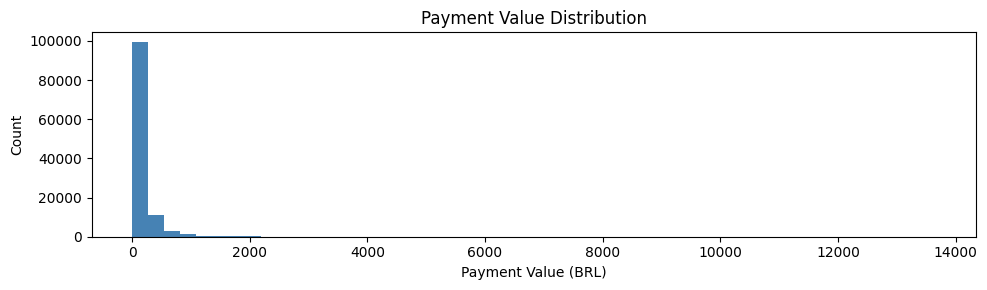

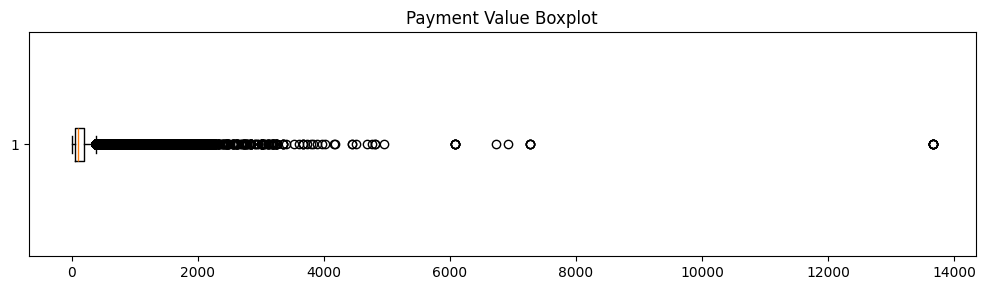

In [6]:
# 셀 6. 결제 금액 분포 확인

print("=== 결제 금액 기본 통계 ===")
print(model_df["payment_value"].describe().round(2))

# 히스토그램
plt.figure(figsize=(10, 3))
plt.hist(model_df["payment_value"], bins=50, color="steelblue")
plt.title("Payment Value Distribution") # 결제 금액 분포
plt.xlabel("Payment Value (BRL)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 박스플롯 (이상치 확인)
plt.figure(figsize=(10, 3))
plt.boxplot(model_df["payment_value"], vert=False)
plt.title("Payment Value Boxplot") # 이상치 확인
plt.tight_layout()
plt.show()

In [7]:
# 셀 7. 이상치 제거
# 상위 1%는 극단적 고가 주문으로 모델 학습을 방해할 수 있습니다.

price_q99   = model_df["price"].quantile(0.99)
freight_q99 = model_df["freight_value"].quantile(0.99)
payment_q99 = model_df["payment_value"].quantile(0.99)

model_df = model_df[
    (model_df["price"]         <= price_q99)   &
    (model_df["freight_value"] <= freight_q99) &
    (model_df["payment_value"] <= payment_q99)
]

print(f"이상치 제거 후 크기: {model_df.shape}")
print(f"결제금액 최대: {model_df['payment_value'].max():.1f} BRL")

이상치 제거 후 크기: (113126, 8)
결제금액 최대: 1202.6 BRL


In [8]:
# 셀 8. 카테고리 처리
# 카테고리 종류가 너무 많으면 컬럼이 많아지므로 TOP 5만 사용

top5 = model_df["product_category_name"].value_counts().head(5).index

model_df["category_simple"] = model_df["product_category_name"].apply(
    lambda x: x if x in top5 else "other"
)

# 카테고리 원핫 인코딩
category_dummies = pd.get_dummies(model_df["category_simple"], prefix="cat")
print("카테고리 컬럼:", list(category_dummies.columns))

카테고리 컬럼: ['cat_beleza_saude', 'cat_cama_mesa_banho', 'cat_esporte_lazer', 'cat_informatica_acessorios', 'cat_moveis_decoracao', 'cat_other']



### 🔵 [1차 모델] ① fit() → 모델 학습


In [9]:
# 셀 9. 1차 모델 - 여러 Feature로 학습 (Feature Importance 확인용)
# 1분
base_X = model_df[["price","freight_value","review_score","year","month","dayofweek"]]
X_all  = pd.concat([base_X, category_dummies], axis=1)
y      = model_df["payment_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

print("1차 모델 학습 중... (약 1분)")
model_all = RandomForestRegressor(n_estimators=100, random_state=42)
model_all.fit(X_train, y_train)
print("학습 완료!")

1차 모델 학습 중... (약 1분)
학습 완료!



### 🔵 [1차 모델] ② predict() → 모델 예측  &  ③ score() → 평가 (MAE / RMSE / R²)


In [10]:
# 셀 10. 1차 모델 평가

pred_all = model_all.predict(X_test)

print("=== 1차 모델 평가 ===")
print(f"MAE  (평균 절대 오차):  {mean_absolute_error(y_test, pred_all):.2f} BRL")
print(f"RMSE (제곱근 평균 오차): {np.sqrt(mean_squared_error(y_test, pred_all)):.2f} BRL")
r2 = r2_score(y_test, pred_all)
print(f"R² Score (설명력):     {r2:.4f}")
print(f"  → 데이터의 약 {r2*100:.1f}%를 설명합니다.")

=== 1차 모델 평가 ===
MAE  (평균 절대 오차):  27.90 BRL
RMSE (제곱근 평균 오차): 54.70 BRL
R² Score (설명력):     0.8569
  → 데이터의 약 85.7%를 설명합니다.


In [11]:
# 셀 11. Feature Importance 확인
# AI가 어떤 입력값을 중요하게 봤는지 확인합니다.

importance_df = pd.DataFrame({
    "feature":    X_all.columns,
    "importance": model_all.feature_importances_
}).sort_values("importance", ascending=False)

print("=== Feature 중요도 순위 ===")
print(importance_df.head(10))
# ▶ price, freight_value가 중요도 높음
# ▶ 카테고리 변수 중요도가 낮으면 최종 모델에서 제외 가능

=== Feature 중요도 순위 ===
                       feature  importance
0                        price    0.668162
1                freight_value    0.164344
4                        month    0.051644
5                    dayofweek    0.043818
2                 review_score    0.028368
3                         year    0.010447
9   cat_informatica_acessorios    0.007569
7          cat_cama_mesa_banho    0.006425
10        cat_moveis_decoracao    0.006262
11                   cat_other    0.005793



### 🔵 [최종 모델] ① fit()  ② predict()  ③ score() → 학습 · 예측 · 평가


In [12]:
# 셀 12. 최종 모델 - 핵심 Feature 3개만 사용
# Feature Importance + 서비스 편의성 고려 → 3개로 단순화

X_final = model_df[["price", "freight_value", "review_score"]]
y_final = model_df["payment_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)

final_model = RandomForestRegressor(n_estimators=100, random_state=42)
final_model.fit(X_train, y_train)

pred_final = final_model.predict(X_test)

print("=== 최종 모델 평가 ===")
print(f"MAE  : {mean_absolute_error(y_test, pred_final):.2f} BRL")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, pred_final)):.2f} BRL")
print(f"R²   : {r2_score(y_test, pred_final):.4f}")

=== 최종 모델 평가 ===
MAE  : 31.13 BRL
RMSE : 62.44 BRL
R²   : 0.8135


In [13]:
# 셀 13. 직접 값 입력 테스트

import pandas as pd  # 이미 불러왔지만 명시적으로 표시

test_cases = [
    [50,   5,  4],
    [200, 10,  2],
    [500, 10,  2],
    [1500, 10, 2],
]

print("=== 예측 테스트 ===")
for case in test_cases:
    sample = pd.DataFrame([case], columns=["price","freight_value","review_score"])
    pred   = final_model.predict(sample)[0]
    print(f"가격={case[0]:>5} / 배송비={case[1]} / 리뷰={case[2]}점 → 예측 결제금액: {pred:.1f} BRL")

=== 예측 테스트 ===
가격=   50 / 배송비=5 / 리뷰=4점 → 예측 결제금액: 204.1 BRL
가격=  200 / 배송비=10 / 리뷰=2점 → 예측 결제금액: 227.4 BRL
가격=  500 / 배송비=10 / 리뷰=2점 → 예측 결제금액: 507.5 BRL
가격= 1500 / 배송비=10 / 리뷰=2점 → 예측 결제금액: 753.8 BRL


In [14]:
# 셀 14. 최종 모델 저장

joblib.dump(final_model, f"{model_path}/part8_sales_model.pkl")
print("매출 예측 모델 저장 완료!")
print("저장 위치:", f"{model_path}/part8_sales_model.pkl")

매출 예측 모델 저장 완료!
저장 위치: /content/drive/MyDrive/Olist/model/part8_sales_model.pkl


---

## 마무리 정리

| 확인할 내용 | 설명 |
|---|---|
| 이 파트의 핵심 | 가격/배송비/리뷰로 결제 금액을 예측합니다. |
| 평가 지표 | 분류와 달리 MAE, RMSE, R²를 사용합니다. |
| Feature 단순화 이유 | 서비스에서 사용자 입력을 줄이기 위함입니다. |
| 다음 단계 | PART 9에서 고객 이탈 가능성을 예측합니다. |